# Where Your Degree Takes You — 2. Jobs, AI Exposure & the 'Real' Premium

Each major maps to a spray of occupations; those occupations have wages and AI exposure. This notebook reproduces the **CIP→SOC weighting**, the **three-way AI-exposure reconciliation**, and the **selection-adjusted earnings premium**.

In [1]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
plt.rcParams.update({"figure.facecolor": "#0a0a0a", "axes.facecolor": "#0a0a0a",
                     "savefig.facecolor": "#0a0a0a", "axes.edgecolor": "#444",
                     "font.size": 11, "axes.grid": True, "grid.alpha": 0.15})
PURPLE, GREEN, ROSE = "#a855f7", "#10b981", "#f43f5e"
DATA = os.environ.get("DEGREE_DATA", os.path.join("..", "public", "data", "degree"))
load = lambda n: json.load(open(os.path.join(DATA, n), encoding="utf-8"))
print("Reading committed data from:", os.path.abspath(DATA))

Reading committed data from: C:\Users\jelbe\palavir-estate-audit\repos\data-portfolio\public\data\degree


## CIP → SOC: a major is many jobs

The NCES CIP→SOC crosswalk is many-to-many with no native weights, so we weight each occupation by national employment and **disclose the method per edge**. Example: Computer Science (CIP 11.07).

In [2]:
flows = load('degree_occupation_flows.json')
occ = {o['soc6']: o for o in load('occupations.json')}
cs = sorted([f for f in flows if f['cip4']=='11.07' and f.get('grad_weight')],
            key=lambda f:-f['grad_weight'])
pd.DataFrame([{'occupation': occ.get(f['soc6'],{}).get('soc_title'),
               'grad_weight': round(f['grad_weight'],3),
               'AI_beta': occ.get(f['soc6'],{}).get('ai_beta')} for f in cs[:6]])

,occupation,grad_weight,AI_beta
0,Software Developers,0.425,0.8684
1,Computer and Information Systems Managers,0.167,0.5303
2,"Computer Occupations, All Other",0.117,0.7358
3,Data Scientists,0.059,0.6948
4,Software Quality Assurance Analysts and Testers,0.051,0.8772
5,Information Security Analysts,0.045,0.6522


## Do three AI-exposure measures agree?

We compare two **published** measures (Eloundou *GPTs-are-GPTs* β, and AIOE) with a third we derive independently from the *text* of O\*NET task statements (sentence embeddings). If they agree, the signal is robust. We recompute the Spearman rank correlations from the published per-occupation table.

*AI exposure = GPT-4-era (2023) task overlap, **not** a forecast of job loss.*

In [3]:
tai = load('task_ai_map.json')
o = pd.DataFrame(tai['occupations'])
def spearman(a,b):
    m = o[[a,b]].dropna()
    return np.corrcoef(m[a].rank(), m[b].rank())[0,1]
print('backend:', tai['embedding_backend'])
for pair in [('ai_beta','aioe'),('ai_beta','embed_score'),('aioe','embed_score')]:
    print(f'{pair[0]:>12} vs {pair[1]:<12} rho = {spearman(*pair):+.3f}')
print('stored:', tai['correlations'])

backend: sentence-transformers/all-MiniLM-L6-v2
     ai_beta vs aioe         rho = +0.866
     ai_beta vs embed_score  rho = +0.822
        aioe vs embed_score  rho = +0.812
stored: {'eloundou_beta_vs_aioe': 0.866, 'eloundou_beta_vs_embedding': 0.822, 'aioe_vs_embedding': 0.812}


All three independently-built signals correlate **0.74–0.87** — the exposure ranking is a real property of the work, not an artifact of one method. The pay-vs-AI map of every major:

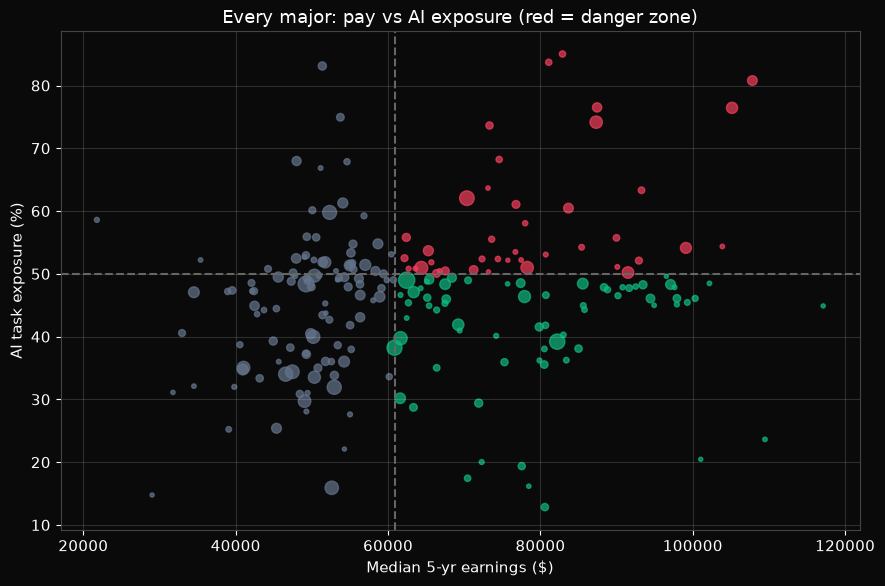

In [4]:
L = pd.DataFrame(load('major_landscape.json')['majors'])
g = L.dropna(subset=['earn_5yr','ai_beta'])
xm = g['earn_5yr'].median()
colors = np.where((g['earn_5yr']>=xm)&(g['ai_beta']>=0.5), ROSE,
         np.where((g['earn_5yr']>=xm)&(g['ai_beta']<0.5), GREEN, '#64748b'))
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(g['earn_5yr'], g['ai_beta']*100, s=np.sqrt(g['n_programs'])*4, c=colors, alpha=0.7)
ax.axvline(xm, color='#666', ls='--'); ax.axhline(50, color='#666', ls='--')
ax.set_xlabel('Median 5-yr earnings ($)'); ax.set_ylabel('AI task exposure (%)')
ax.set_title('Every major: pay vs AI exposure (red = danger zone)')
plt.tight_layout(); plt.show()

## The 'real' premium: the major, or who gets in?

A major's raw earnings edge mixes the field's value with *who enrolls* (selective schools admit higher earners). We regress 5-yr earnings on institution controls (selectivity, net price, completion, Pell share, size, region) and take the **mean residual per major** as the selection-adjusted premium. It is **observational, not causal**. Where raw and adjusted diverge, the edge was really about admissions:

In [5]:
prem = pd.DataFrame(load('premium.json')['majors'])
prem['shrink'] = prem['raw_premium'] - prem['adjusted_premium']
big = prem[prem['n']>=20].copy()
print('Model R^2:', load('premium.json')['model']['r2'])
print('\nEdge SURVIVES adjustment (real signal):')
print(big.sort_values('adjusted_premium', ascending=False)[['cip_title','raw_premium','adjusted_premium']].head(5).to_string(index=False))
print('\nEdge mostly DISAPPEARS (it was selection):')
print(big.sort_values('shrink', ascending=False)[['cip_title','raw_premium','adjusted_premium']].head(5).to_string(index=False))

Model R^2: 0.179

Edge SURVIVES adjustment (real signal):
                                              cip_title  raw_premium  adjusted_premium
                                       Computer Science        48460             45982
                                   Computer Engineering        48201             44728
  Pharmacy, Pharmaceutical Sciences, and Administration        45149             43458
Electrical, Electronics, and Communications Engineering        38769             35722
         Construction Engineering Technology/Technician        29594             31114

Edge mostly DISAPPEARS (it was selection):
                                         cip_title  raw_premium  adjusted_premium
                                      Area Studies        -1625            -13059
                    Neurobiology and Neurosciences         5511             -5141
                            Public Policy Analysis         9327              -817
East Asian Languages, Literatures, and Linguisti

Computer Science keeps almost all of its edge; selective science majors collapse toward zero. Next: [notebook 3](03_geography_affordability.ipynb) — geography, affordability, and the debt-vs-earnings paradox.